# Myxospores isolation (individual fruiting bodies)

------------

Experiment aimed at determining the properties/physical parameters of myxospores and the composition of a fruiting body.

### **Protocol**
Myxospores isolation using determined protocol below:

- Imaging Fruiting Bodies (FBs) pre-/post-harvest
- Harvest 20 FBs in either:
    - 100 µL BSA (*200 concentration condition*)
    - 1 mL BSA (*Usual condition*)
- 2·washing: centrifugation 10 min at $8000×g$ with MM
- Complete volume to 200 µL (*200 concentration condition*) and 2 mL (*Usual condition*)
- Sonication: *Time* 2 min, *Pulse* 10 sec ON | 15 sec OFF, *Amplitude* 28%, *Probe* 60-62k
- Heat Treatment 2 h
- <ins>Only for *Usual condition*</ins>: Concentration at 200 µL then homogenisation (2nd sonication) *Time* 30 sec at same parameters (c.f. 1st sonication parameters above)
- Imaging at ×40 in phase contrast and fluorescence using Malassez slide (counting chamber)


### **Imaging**
- FBs colonies were observed under stereoscope olympus
- Spores and vegettives cells were observed under epifluorescence microscope TIE


### **Image processing**
Image processing was done using:
- Fiji version 2.16.0 / ImageJ 1.54p ; Java 1.8.0_452
- Labkit - Pixel Classification plugin fiji integrated
- Python 3.14.6 | packaged by conda-forge

In [1]:
# Packages
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import openpyxl
import seaborn as sns

In [2]:
# Functions  
def concentration(df, N_objects):
    '''
    # Compute the concentration of objects/µL and objects/FB
    ▬ Inputs
        - df (pandas.dataframe): Dataframe
        - N_objects (pandas.Series): Objects
    ▬ Output
        - df (pandas.dataframe): Dataframe modified with computed data
    '''
       
    # Mean concentration in sp/µL
    df['Concentration_µL'] = df[N_objects] * 1000/2.704

    # Concentration of spores/FB
    df['N_objects/FB'] = df['Concentration_µL']*200/20

    return df



def group_identification(df):
    '''
    # Compute the group identification from date within image ID, a group per replicate
    ▬ Inputs
        - df (pandas.dataframe): Dataframe
    ▬ Output
        - df (pandas.dataframe): Dataframe modified with computed data
    '''
    
    Group = []
    
    for name in df['Image_ID']:
        if name[:8] == '20260727':
            Group.append(1)
        elif name[:8] == '20260729':
            Group.append(2)
        else:
            Group.append(3)
            
    df['Group'] = Group

    return df



def condition_identification(df):
    '''
    # Compute the condition identification from experimental condition within image ID
    ▬ Inputs
        - df (pandas.dataframe): Dataframe
    ▬ Output
        - df (pandas.dataframe): Dataframe modified with computed data
    '''
    
    # Identification per experimental condition
    Condition = []
    
    for condition in df_aw_mean['Image_ID']:
        
        if condition[22:32] == '200_microL':
            Condition.append('200_concentrated')
        else:
            Condition.append('Homogenised')
    
    df_aw_mean['Condition_protocol'] = Condition

    return df



def pixel_adjustments(df, magnification):
    '''
    # Compute pixel adjustments according to microscope calibration and magnification
    ▬ Inputs
        - df (pandas.dataframe): Dataframe
        - magnification (int/float): Microscope magnification for imaging
    ▬ Output
        - df (pandas.dataframe): Dataframe modified with computed data
    '''
    
    # Pixel size - Microscope calibration
    y0 = 6.91735833895
    gamma = 1.0306633305249997

    # Pixel size at the given magnification
    y = y0 * magnification ** -gamma

    # Adjust surface area
    df['Surface_area'] *= y

    return df



def mean_df(df, by, column):
    '''
    # Compute mean values in a column(s) dataframe of your choosing using pandas functions 
    ▬ Inputs
        - df (pandas.dataframe): Dataframe
        - by (list of str): Columns of the dataframe to groupby
        - column (str): Column to compute the mean
    ▬ Output
        - df (pandas.dataframe): Dataframe modified with computed data
    '''
    
    df_mean = df.groupby(by, as_index=False)[column].mean()

    return df_mean

#### **1)** <ins>Spore concentration</ins>

Original dataframe: <ins>20260804_Myxospores_isolation_isolated_FB_protocol_conditions.xlsx</ins> - Manual count of objects from imaging

Features:
- Image_ID: File name
- Condition_protocol: Experimental condition
- N_clumps: Number of clumps observed (arbitrary measurement, clumps = 3 cells minimum touching together)
- Manual_count_objects: Objects counted by hand on fiji
- Object_type: Differenciation between cell types: spores ("Spore") and vegetative cells ("VC")

In [3]:
# Path-to-file
df_count = pd.read_excel(r"C:/Users/thiba/Documents/University/Internship/LCB_M_xanthus/Data/20260804_Myxospores_isolation_isolated_FB_protocol_conditions.xlsx")

# Dataframe with only features of interest
df_mean_concentration = df_count[['Image_ID', 'Condition_protocol', 'Object_type', 'Manual_count_objects']].copy()

##### Concentration Spores/FB:

 Symbols | Terms | Current data
 :-------|:---- | -----: 
 $V_{H}$  | Volume harvest | 200 µL 
 $V_{cc}$  | Volume calculated in counting chamber | 2.704 nL 
 $N_{Spores}$  | Number of spores counted | df_count[*'Manual_count_objects'*] 
 $N_{FBs}$  | Number of fruiting bodies harvested | 20 

<br>

$$[Spores/FB] = \frac{V_{H} \ \cdot [Spores/\mu L] }{N_{FBs}} = \frac{V_{H}\cdot \frac{N_{Spores}}{V_{c.c.}} \cdot 1000}{N_{FBs}}$$


In [4]:
# Compute data (Identification, Mean, Concentrations)
df_mean_concentration = group_identification(df_mean_concentration)

df_mw = df_mean_concentration.copy() # For direct comparison w/ automated workflow further below 

df_mean_concentration = mean_df(df_mean_concentration, by=['Group', 'Condition_protocol', 'Object_type'], column='Manual_count_objects')
df_mean_concentration = concentration(df_mean_concentration, 'Manual_count_objects')

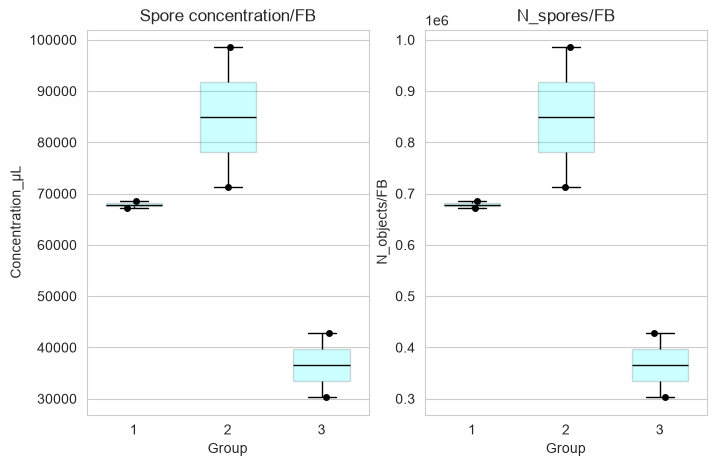

In [8]:
# Plots
subset = df_mean_concentration[df_mean_concentration['Object_type']=='Spore']

sns.set_style("whitegrid")
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(8,5))

sns.boxplot(
    data=subset,
    x="Group",
    y="Concentration_µL",
    boxprops=dict(facecolor="cyan", alpha=0.2),
    medianprops=dict(color="black"),
    whiskerprops=dict(color="black"),
    capprops=dict(color="black"),
    fliersize=0,
    width=0.6,
    ax=ax[0]
)

sns.stripplot(
    data=subset,
    x="Group",
    y="Concentration_µL",
    jitter=0.1,
    color="black",
    size=5,
    ax=ax[0]
)

ax[0].set_title("Spore concentration/FB")

sns.boxplot(
    data=subset,
    x="Group",
    y="N_objects/FB",
    boxprops=dict(facecolor="cyan", alpha=0.2),
    medianprops=dict(color="black"),
    whiskerprops=dict(color="black"),
    capprops=dict(color="black"),
    fliersize=0,
    width=0.6,
    ax=ax[1]
)

sns.stripplot(
    data=subset,
    x="Group",
    y="N_objects/FB",
    jitter=0.1,
    color="black",
    size=5,
    ax=ax[1]
)

ax[1].set_title("N_spores/FB")

plt.show()

#### **2)** <ins>FB measurements</ins>

Original dataframe: Folder <ins>20260804_measurements_FB_colonies</ins> - FBs colonies measurements from fiji

Description:
  - Measurements of FB area
  - One dataframe per group per experimental condition

Experiment:
  - (1) Imaging FBs plates
  - (2) Harvest of 20 FBs per experimental condition
  - (3) Myxospores isolation protocol
  - Experimental conditions:
    - *200_concentrated*: 200 µL concentrated solution (without homogenisation)
    - *Homogenised*: 'Usual' protocol (with homogenisation)

Features:
  - *Area* (float): Area of a FB in pixels
  - Other features are uninteresting

In [16]:
# Path-to-files
df_msrmt_1_1 = pd.concat([
    pd.read_csv(r"C:/Users/thiba/Documents/University/Internship/LCB_M_xanthus/Data/20260804_measurements_FB_colonies/20260804_Measurements_FB_size_Group_1-1_concentrated.csv"),
    pd.read_csv(r"C:\Users\thiba\Documents\University\Internship\LCB_M_xanthus\Data\20260804_measurements_FB_colonies\20260804_Measurements_FB_size_Group_1-2_concentrated.csv")
])

df_msrmt_1_2 = pd.concat([
    pd.read_csv(r"C:\Users\thiba\Documents\University\Internship\LCB_M_xanthus\Data\20260804_measurements_FB_colonies\20260804_Measurements_FB_size_Group_1-1_usual.csv"),
    pd.read_csv(r"C:\Users\thiba\Documents\University\Internship\LCB_M_xanthus\Data\20260804_measurements_FB_colonies\20260804_Measurements_FB_size_Group_1-2_usual.csv")
])

df_msrmt_2_1 = pd.read_csv(r"C:\Users\thiba\Documents\University\Internship\LCB_M_xanthus\Data\20260804_measurements_FB_colonies\20260804_Measurements_FB_size_Group_2_concentrated.csv")
df_msrmt_2_2 = pd.read_csv(r"C:\Users\thiba\Documents\University\Internship\LCB_M_xanthus\Data\20260804_measurements_FB_colonies\20260804_Measurements_FB_size_Group_2_usual.csv")

df_msrmt_3_1 = pd.read_csv(r"C:\Users\thiba\Documents\University\Internship\LCB_M_xanthus\Data\20260804_measurements_FB_colonies\20260804_Measurements_FB_size_Group_3_concentrated.csv")
df_msrmt_3_2 = pd.read_csv(r"C:\Users\thiba\Documents\University\Internship\LCB_M_xanthus\Data\20260804_measurements_FB_colonies\20260804_Measurements_FB_size_Group_3_usual.csv")

In [50]:
# Group assignation and tidy dataframe
data_files = {
    "1": {
        "Concentrated": df_msrmt_1_1,
        "Usual": df_msrmt_1_2
        },
    "2": {
        "Concentrated": df_msrmt_2_1,
        "Usual": df_msrmt_2_2
        },
    "3": { 
        "Concentrated": df_msrmt_3_1,
        "Usual": df_msrmt_3_2
        }
}

for group, conditions in data_files.items():
    for condition, df in conditions.items():
        df["Group"] = group
        df["Condition"] = condition

df_msrmt = pd.concat(
    [df for conditions in data_files.values() for df in conditions.values()],
    ignore_index=True
)

# Convert group value into int value
df_msrmt['Group'] = df_msrmt['Group'].astype(int)

# Drop unnecessary features (Index, Mean, Min, Max)
df_msrmt = df_msrmt.drop(df_msrmt.columns[[0, 2, 3 ,4]], axis=1)

# Rename and convert surface area feature into float value
df_msrmt = df_msrmt.rename(columns={'Area':'Surface_area'})
df_msrmt['Surface_area'] = df_msrmt['Surface_area'].astype(float)

# Adjust surface area in function of magnification
df_msrmt = pixel_adjustments(df_msrmt, 1)
df_msrmt

,Surface_area,Group,Condition
0,4095.076137,1,Concentrated
1,2905.290502,1,Concentrated
2,5603.060255,1,Concentrated
3,6557.655705,1,Concentrated
4,4337.183679,1,Concentrated
...,...,...,...
121,7090.292297,3,Usual
122,5928.176096,3,Usual
123,7062.622864,3,Usual
124,14021.485353,3,Usual


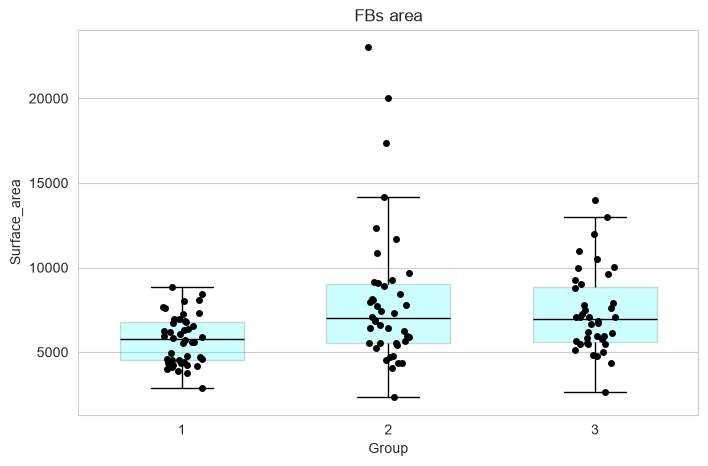

In [19]:
# Plot FBs area
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(8,5))

sns.boxplot(
    data=df_msrmt,
    x="Group",
    y="Surface_area",
    boxprops=dict(facecolor="cyan", alpha=0.2),
    medianprops=dict(color="black"),
    whiskerprops=dict(color="black"),
    capprops=dict(color="black"),
    fliersize=0,
    width=0.6,
    ax=ax
)

sns.stripplot(
    data=df_msrmt,
    x="Group",
    y="Surface_area",
    jitter=0.1,
    color="black",
    size=5,
    ax=ax
)

ax.set_title("FBs area")

plt.show()

In [21]:
# Merge measurements to concentration dataframe
df_msrmt_mean = mean_df(df_msrmt, by=['Group'], column='Surface_area')

df_all = pd.merge(
    df_mean_concentration,
    df_msrmt_mean,
    on='Group',
    how='left',
    validate='many_to_one'
)

df_all = df_all.rename(columns={'Surface_area': 'FB_area'})

df_msrmt_mean
df_all

,Group,Condition_protocol,Object_type,Manual_count_objects,Concentration_µL,N_objects/FB,FB_area
0,1,200_concentrated,Spore,185.142857,68469.991547,684699.915469,5745.180526
1,1,200_concentrated,VC,2.142857,792.476754,7924.767540,5745.180526
2,1,Homogenised,Spore,181.875000,67261.464497,672614.644970,5745.180526
3,1,Homogenised,VC,1.000000,369.822485,3698.224852,5745.180526
4,2,200_concentrated,Spore,193.000000,71375.739645,713757.396450,8068.769104
5,2,200_concentrated,VC,0.375000,138.683432,1386.834320,8068.769104
6,2,Homogenised,Spore,266.555556,98578.238001,985782.380013,8068.769104
7,2,Homogenised,VC,1.666667,616.370809,6163.708087,8068.769104
8,3,200_concentrated,Spore,115.875000,42853.180473,428531.804734,7348.655631
9,3,200_concentrated,VC,0.625000,231.139053,2311.390533,7348.655631


#### **3)** <ins>Rough volume of a FB</ins>

To calculate the volume of a fruiting body, we consider the volume of a spore as cubic $V_{Spore} = diameter^3$, and the volume of FB as a homogenous rectangular parallelepiped $V_{FB} = (x\cdot d^3)(y\cdot d^3)(z\cdot d^3)$ with $(x\cdot d^3)(y\cdot d^3) \subset \alpha$<br>($\alpha$  : the mean surface area of spore observed from above)

Original dataframe: <ins>20260811_Myxospores_size.xlsx</ins> - Spores' diameter manual measurement

- Description:
  - FBs plates observed
  - Spores' size manual measurements on Fiji
  - Three replicates in the dataset (one replicate per day): *27/07/2026*, *29/07/2026* & *04/08/2026* 
- Experiment:
  - (1) Imaging FBs plates
  - (2) Harvest of 20 FBs per experimental condition
  - (3) Myxospores isolation protocol
  - Experimental conditions:
    - *200_concentrated*: 200 µL concentrated solution (without homogenisation)
    - *Homogenised*: 'Usual' protocol (with homogenisation)
- Features:
  - *Image_ID* (str): Image identification 
  - *Condition_protocol* (str): Experimental conditions
  - *Size_µm* (float): Manual measurement in µm

In [23]:
# Path-to-file
spore_size = pd.read_excel(r"C:\Users\thiba\Documents\University\Internship\LCB_M_xanthus\Data\20260811_Myxospores_size.xlsx")

In [24]:
# Spore size
d = (spore_size['Size_µm'].mean()) # Mean diameter
sp_volume = d**3                   # Spore volume

In [26]:
# Set up new columns
df_all['Volume_FB'] = np.nan
df_all['N_spores_FB_base_surface'] = np.nan
df_all['FB_height'] = np.nan

# FB properties
vc_erase = df_all['Object_type'] != 'VC'   # Exclude VC because we do not consider it in fruiting bodies

df_all.loc[vc_erase, 'Volume_FB_nL'] = df_all.loc[vc_erase, 'N_objects/FB'] * d**3 / 10**6
df_all.loc[vc_erase, 'N_spores_FB_base_surface'] = df_all.loc[vc_erase, 'FB_area'] / d**2
df_all.loc[vc_erase, 'FB_height'] = (df_all.loc[vc_erase, 'N_objects/FB'] / df_all.loc[vc_erase, 'N_spores_FB_base_surface']  * d)

df_all = df_all[[
    'Group', 
    'Condition_protocol', 
    'Object_type',
    'Manual_count_objects', 
    'Concentration_µL', 
    'N_objects/FB',
    'FB_area',
    'N_spores_FB_base_surface',
    'FB_height',
    'Volume_FB_nL'
]]

df_all

,Group,Condition_protocol,Object_type,Manual_count_objects,Concentration_µL,N_objects/FB,FB_area,N_spores_FB_base_surface,FB_height,Volume_FB_nL
0,1,200_concentrated,Spore,185.142857,68469.991547,684699.915469,5745.180526,1054.130691,1516.388307,8.711925
1,1,200_concentrated,VC,2.142857,792.476754,7924.767540,5745.180526,NaN,NaN,NaN
2,1,Homogenised,Spore,181.875000,67261.464497,672614.644970,5745.180526,1054.130691,1489.623352,8.558155
3,1,Homogenised,VC,1.000000,369.822485,3698.224852,5745.180526,NaN,NaN,NaN
4,2,200_concentrated,Spore,193.000000,71375.739645,713757.396450,8068.769104,1480.464733,1125.530236,9.081644
5,2,200_concentrated,VC,0.375000,138.683432,1386.834320,8068.769104,NaN,NaN,NaN
6,2,Homogenised,Spore,266.555556,98578.238001,985782.380013,8068.769104,1480.464733,1554.488795,12.542811
7,2,Homogenised,VC,1.666667,616.370809,6163.708087,8068.769104,NaN,NaN,NaN
8,3,200_concentrated,Spore,115.875000,42853.180473,428531.804734,7348.655631,1348.337690,741.974528,5.452515
9,3,200_concentrated,VC,0.625000,231.139053,2311.390533,7348.655631,NaN,NaN,NaN


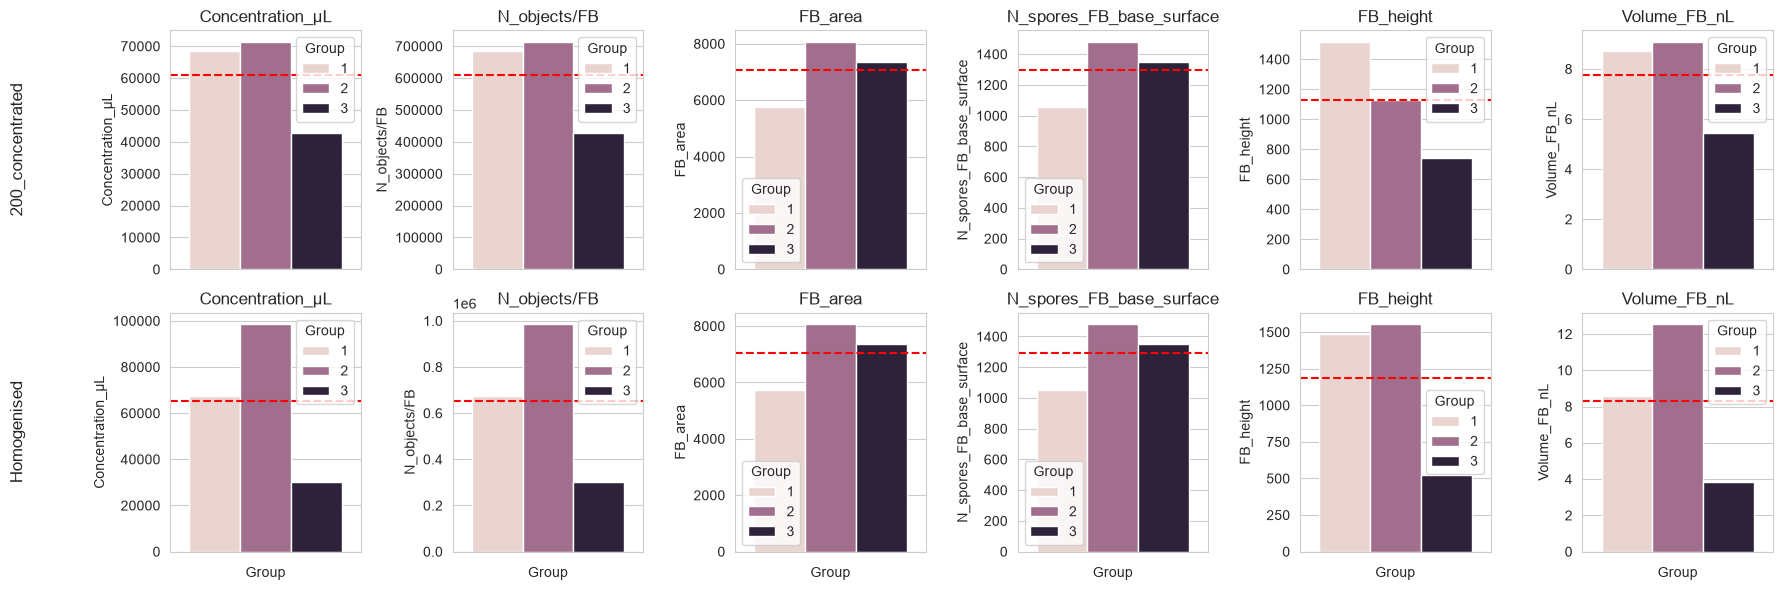

In [84]:
# Plot features (spores only)
subset = df_all[df_all['Object_type'] == 'Spore']

parameters = [
    'Concentration_µL',
    'N_objects/FB',
    'FB_area',
    'N_spores_FB_base_surface',
    'FB_height',
    'Volume_FB_nL'
]

conditions = subset['Condition_protocol'].unique()
groups = subset['Group'].unique()

fig, axs = plt.subplots(
    nrows=len(conditions),
    ncols=len(parameters),
    figsize=(18, 6),
    squeeze=False,
    sharex=True
)

for i, cdt in enumerate(conditions):
    for j, prm in enumerate(parameters):

        subset_plot = subset[
            subset['Condition_protocol'] == cdt
        ]

        ax = axs[i, j]

        sns.barplot(
            data=subset_plot,
            hue='Group',
            y=prm,
            ax=ax
        )

        mean_value = subset_plot[prm].mean()

        ax.axhline(
            mean_value,
            color='red',
            linestyle='--',
            linewidth=1.5
        )

        ax.set_title(f'{prm}')
        ax.set_xlabel('Group')

        if j == 0:
            ax.text(
                -0.8, 0.5,
                f"{cdt}",
                transform=ax.transAxes,
                rotation=90,
                ha="center",
                va="center",
                fontsize=12
            )


plt.tight_layout()
plt.show()

#### **4)** <ins>Automated workflow results</ins>

Original dataframe: <ins>20260812_Results_automated_workflow.csv</ins> - Automaton processing images (counting and first analysis)


Description:
  - Myxospores isolation protocol's application for indidividual FBs
  - Output dataset from images processed automatically with a python script (c.f. Automated_workflow)


Experiment:
  - (1) Imaging FBs plates
  - (2) Harvest of 20 FBs per experimental condition
  - (3) Myxospores isolation protocol
  - Experimental conditions:
    - *200_concentrated*: 200 µL concentrated solution (without homogenisation)
    - *Homogenised*: 'Usual' protocol (with homogenisation)


Features:
  - *Image_ID* (str): Image identification 
  - *Label* (int): Labelled object (scikit-image `regionprops`)
  - *Cell_type* (str): Differenciation between cell types - spores ("Spore") and vegetative cells ("VC")
  - *Area* (float): 'Area', here the volume in hyperstacked images (scikit-image `regionprops`)
  - *Volume* (float): Volume computed
  - *Surface_area* (float): Surface_area of the cell (scikit-image `regionprops`)
  - *Sphericity* (float): Sphericity computed
  - *Axis_major_length* (float): Axis major length (scikit-image `regionprops`)
  - *Axis_minor_length* (float): Axis minor length (scikit-image `regionprops`)

In [51]:
# Path-to-file
df_aw = pd.read_csv(r"C:\Users\thiba\Documents\University\Internship\LCB_M_xanthus\Data\20260812_Results_automated_workflow.csv")

# Drop unnecessary features (Index, Labels, Area)
df_aw = df_aw.drop(df_aw.columns[[0, 2, 4]], axis=1)

df_aw

,Image_ID,Cell_type,Volume,Surface_area,Sphericity,Axis_major_length,Axis_minor_length
0,20260727_isolated_FBs_200_microL_001_C2_segmen...,spore,7.966222,18.425490,1.046888,2.851754,1.990538
1,20260727_isolated_FBs_200_microL_001_C2_segmen...,spore,7.703311,20.076915,0.939519,4.088701,2.219733
2,20260727_isolated_FBs_200_microL_001_C2_segmen...,spore,8.649793,37.896257,0.537723,5.144152,2.165391
3,20260727_isolated_FBs_200_microL_001_C2_segmen...,spore,14.433849,41.542018,0.690109,5.294710,2.070533
4,20260727_isolated_FBs_200_microL_001_C2_segmen...,spore,6.730538,15.678259,1.099561,3.319429,1.454880
...,...,...,...,...,...,...,...
4493,20260804_isolated_FBs_usual_008_C2_segmentation,spore,5.521144,17.491272,0.863672,2.325184,2.018255
4494,20260804_isolated_FBs_usual_008_C2_segmentation,spore,10.726795,29.334243,0.801843,3.596365,2.406956
4495,20260804_isolated_FBs_usual_008_C2_segmentation,spore,7.335235,21.737041,0.839898,3.281850,1.904407
4496,20260804_isolated_FBs_usual_008_C2_segmentation,vc,5.521144,56.764086,0.266132,4.234641,2.436283


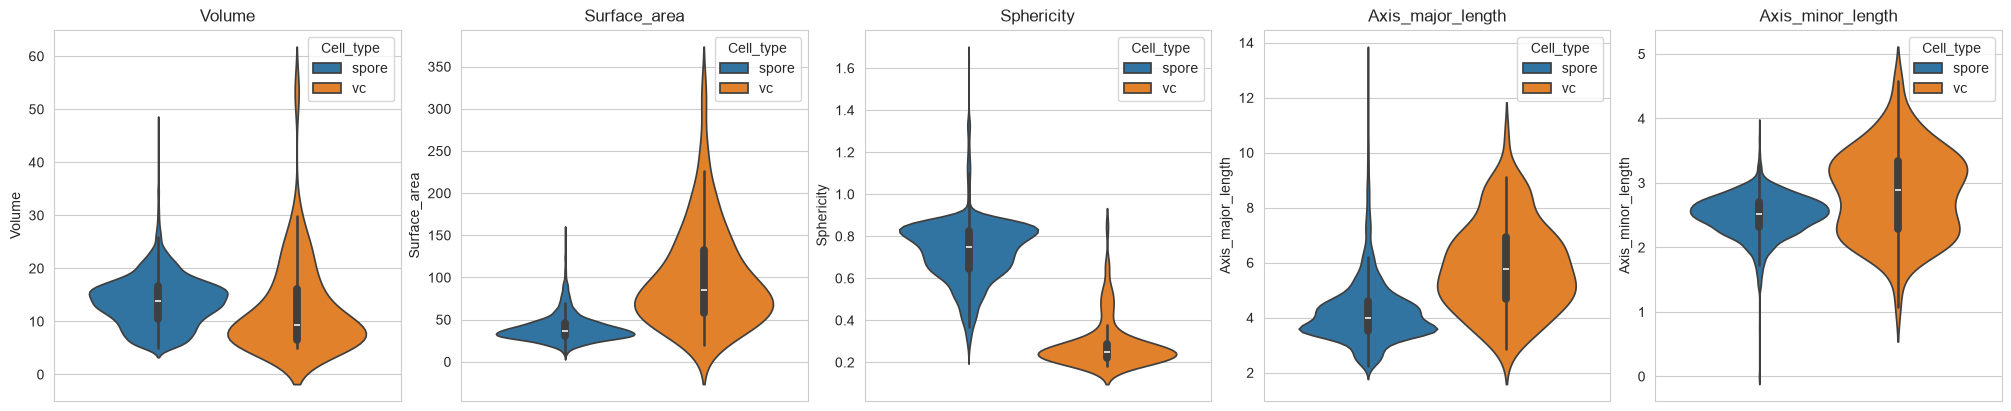

In [83]:
# Plot features
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(20, 4), layout="constrained")

cols = ['Volume', 'Surface_area', 'Sphericity',
        'Axis_major_length', 'Axis_minor_length']

for ax, col in zip(axes, cols):

    sns.violinplot(
        data=df_aw,
        hue='Cell_type',
        y=col,
        width=0.8,
        # color="Cell_type",
        ax=ax
    )

    ax.set_title(col)

plt.show()

In [81]:
# Identification per condition and per group (each group corresponding to a replicat)
df_aw_mean = df_aw.copy()

df_aw_mean = condition_identification(df_aw_mean)
df_aw_mean = group_identification(df_aw_mean)


# Sum labelled object per image
df_aw_mean['N_objects'] = (
    df_aw_mean
    .groupby(['Image_ID', 'Cell_type', 'Condition_protocol', 'Group'])['Image_ID']
    .transform('size')
)


# Mean values per image according Image_ID, Cell_type, Condition_protocol, Group
df_aw_mean = (
    df_aw_mean
    .groupby(by=['Image_ID', 'Cell_type', 'Condition_protocol', 'Group'], as_index=False)
    .mean()
    # .reset_index()
)

df_aw_mean['Group'] = df_aw_mean['Group'].astype(int)

df_aw_mean = df_aw_mean[[
    'Image_ID',
    'Group', 
    'Condition_protocol', 
    'Cell_type',
    'N_objects',
    'Volume',
    'Surface_area', 	
    'Sphericity',
    'Axis_major_length', 	
    'Axis_minor_length',
]]
df_aw_mean

,Image_ID,Group,Condition_protocol,Cell_type,N_objects,Volume,Surface_area,Sphericity,Axis_major_length,Axis_minor_length
0,20260727_isolated_FBs_200_microL_001_C2_segmen...,1,200_concentrated,spore,143.0,7.094753,23.612459,0.826666,4.119279,1.787904
1,20260727_isolated_FBs_200_microL_001_C2_segmen...,1,200_concentrated,vc,2.0,6.493917,39.091469,0.565477,4.613945,2.252341
2,20260727_isolated_FBs_200_microL_003_C2_segmen...,1,200_concentrated,spore,144.0,15.439120,50.022517,0.628752,5.379869,2.422870
3,20260727_isolated_FBs_200_microL_003_C2_segmen...,1,200_concentrated,vc,3.0,11.594403,91.951109,0.273116,5.719960,2.842234
4,20260727_isolated_FBs_200_microL_004_C2_segmen...,1,200_concentrated,spore,137.0,14.733798,52.851510,0.585438,5.622462,2.349190
5,20260727_isolated_FBs_200_microL_004_C2_segmen...,1,200_concentrated,vc,3.0,9.236962,84.312107,0.254510,6.407744,3.091605
6,20260727_isolated_FBs_200_microL_005_C2_segmen...,1,200_concentrated,spore,192.0,14.872308,52.389239,0.596571,5.653577,2.357107
7,20260727_isolated_FBs_200_microL_005_C2_segmen...,1,200_concentrated,vc,8.0,12.248396,103.237265,0.251669,5.884735,2.869155
8,20260727_isolated_FBs_200_microL_006_C2_segmen...,1,200_concentrated,spore,199.0,13.908290,46.763022,0.621466,5.128043,2.325479
9,20260727_isolated_FBs_200_microL_006_C2_segmen...,1,200_concentrated,vc,5.0,11.741633,97.074417,0.256478,5.921858,2.816920


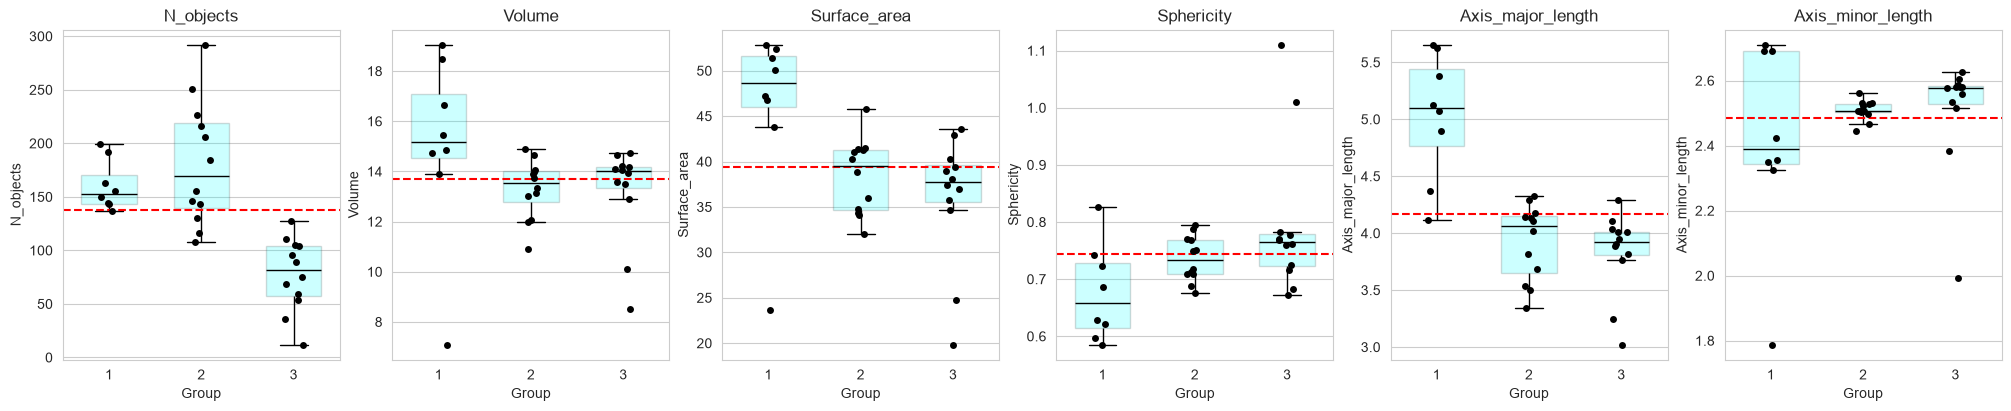

In [82]:
# Plot features (spores only)
subset_spores = df_aw_mean[df_aw_mean['Cell_type'] == 'spore']

susbset = df_aw_mean[df_aw_mean['Cell_type']=='spore']
cols = ['N_objects', 'Volume', 'Surface_area', 'Sphericity', 'Axis_major_length', 'Axis_minor_length']

sns.set_style("whitegrid")
fig, axes = plt.subplots(nrows=1, ncols=6, figsize=(20, 4), layout="constrained")

for ax, col in zip(axes, cols):

    sns.boxplot(
        data=susbset,
        x="Group",
        y=col,
        boxprops=dict(facecolor="cyan", alpha=0.2),
        medianprops=dict(color="black"),
        whiskerprops=dict(color="black"),
        capprops=dict(color="black"),
        fliersize=0,
        width=0.6,
        ax=ax
    )
    
    sns.stripplot(
        data=susbset,
        x="Group",
        y=col,
        jitter=0.1,
        color="black",
        size=5,
        ax=ax
    )

    mean_value = subset_spores[col].mean()

    ax.axhline(
        mean_value,
        color='red',
        linestyle='--',
        linewidth=1.5
    )

    ax.set_title(col)
    ax.set_ylabel(f'{col}')


    
plt.show()

#### **5)** <ins>Comparison - Automated workflow (AW) and Manual workflow (MW)</ins>

In [68]:
# Merge both automated and manual workflow

# Normalized dataframe (Image_ID, Object_type, N_object, Workflow)
mask = df_aw_mean['Image_ID'].str.len() == 52

df_aw_mean.loc[mask, 'Image_ID'] = df_aw_mean.loc[mask, 'Image_ID'].str[:36]
df_aw_mean.loc[~mask, 'Image_ID'] = df_aw_mean.loc[~mask, 'Image_ID'].str[:31]


df_aw_mean = df_aw_mean.rename(columns={'Cell_type':'Object_type', 'N_objects':'N_object'})
df_aw_mean['Workflow'] = 'Automated'
df_mw = df_mw.rename(columns={'Manual_count_objects':'N_object'})
df_mw['Workflow'] = 'Manual'


# Concat 
df_aw_mw = pd.concat([df_mw, df_aw_mean], ignore_index=True)
df_aw_mw = df_aw_mw[[
    'Image_ID',
    'Workflow', 
    'Group', 
    'Condition_protocol', 
    'Object_type', 
    'N_object',
    'Volume', 
    'Surface_area', 
    'Sphericity', 
    'Axis_major_length',
    'Axis_minor_length'
]]

df_aw_mw = concentration(df_aw_mw, 'N_object')
df_aw_mw

,Image_ID,Workflow,Group,Condition_protocol,Object_type,N_object,Volume,Surface_area,Sphericity,Axis_major_length,Axis_minor_length,Concentration_µL,N_objects/FB
0,20260727_isolated_FBs_200_microL_001,Manual,1,200_concentrated,Spore,186.0,NaN,NaN,NaN,NaN,NaN,68786.982249,687869.822485
1,20260727_isolated_FBs_200_microL_001,Manual,1,200_concentrated,VC,4.0,NaN,NaN,NaN,NaN,NaN,1479.289941,14792.899408
2,20260727_isolated_FBs_200_microL_002,Manual,1,200_concentrated,Spore,182.0,NaN,NaN,NaN,NaN,NaN,67307.692308,673076.923077
3,20260727_isolated_FBs_200_microL_002,Manual,1,200_concentrated,VC,1.0,NaN,NaN,NaN,NaN,NaN,369.822485,3698.224852
4,20260727_isolated_FBs_200_microL_003,Manual,1,200_concentrated,Spore,151.0,NaN,NaN,NaN,NaN,NaN,55843.195266,558431.952663
...,...,...,...,...,...,...,...,...,...,...,...,...,...
149,20260804_isolated_FBs_usual_004,Automated,3,Homogenised,vc,3.0,7.247597,58.056203,0.361462,4.370673,2.391971,1109.467456,11094.674556
150,20260804_isolated_FBs_usual_006,Automated,3,Homogenised,spore,54.0,14.179701,37.020474,0.767920,3.945911,2.581635,19970.414201,199704.142012
151,20260804_isolated_FBs_usual_006,Automated,3,Homogenised,vc,1.0,11.410365,37.447990,0.654519,3.626948,2.302761,369.822485,3698.224852
152,20260804_isolated_FBs_usual_008,Automated,3,Homogenised,spore,105.0,12.914470,34.650987,0.783212,3.768390,2.517112,38831.360947,388313.609467


In [79]:
# Compute diameter and volume and normalize the Object_type classification (differences between two dataframes)
df_aw_mw.loc[
    (df_aw_mw['Workflow'] == 'Manual') &
    (df_aw_mw['Object_type'] == 'Spore'),
    'Axis_minor_length'
] = d

df_aw_mw.loc[
    (df_aw_mw['Workflow'] == 'Manual') &
    (df_aw_mw['Object_type'] == 'Spore'),
    'Volume'
] = sp_volume


df_aw_mw['Object_type'] = (
    df_aw_mw['Object_type']
    .astype(str)
    .str.strip()
    .str.capitalize()
)

df_aw_mw

,Image_ID,Workflow,Group,Condition_protocol,Object_type,N_object,Volume,Surface_area,Sphericity,Axis_major_length,Axis_minor_length,Concentration_µL,N_objects/FB
0,20260727_isolated_FBs_200_microL_001,Manual,1,200_concentrated,Spore,186.0,12.723712,NaN,NaN,NaN,2.334558,68786.982249,687869.822485
1,20260727_isolated_FBs_200_microL_001,Manual,1,200_concentrated,Vc,4.0,NaN,NaN,NaN,NaN,NaN,1479.289941,14792.899408
2,20260727_isolated_FBs_200_microL_002,Manual,1,200_concentrated,Spore,182.0,12.723712,NaN,NaN,NaN,2.334558,67307.692308,673076.923077
3,20260727_isolated_FBs_200_microL_002,Manual,1,200_concentrated,Vc,1.0,NaN,NaN,NaN,NaN,NaN,369.822485,3698.224852
4,20260727_isolated_FBs_200_microL_003,Manual,1,200_concentrated,Spore,151.0,12.723712,NaN,NaN,NaN,2.334558,55843.195266,558431.952663
...,...,...,...,...,...,...,...,...,...,...,...,...,...
149,20260804_isolated_FBs_usual_004,Automated,3,Homogenised,Vc,3.0,7.247597,58.056203,0.361462,4.370673,2.391971,1109.467456,11094.674556
150,20260804_isolated_FBs_usual_006,Automated,3,Homogenised,Spore,54.0,14.179701,37.020474,0.767920,3.945911,2.581635,19970.414201,199704.142012
151,20260804_isolated_FBs_usual_006,Automated,3,Homogenised,Vc,1.0,11.410365,37.447990,0.654519,3.626948,2.302761,369.822485,3698.224852
152,20260804_isolated_FBs_usual_008,Automated,3,Homogenised,Spore,105.0,12.914470,34.650987,0.783212,3.768390,2.517112,38831.360947,388313.609467


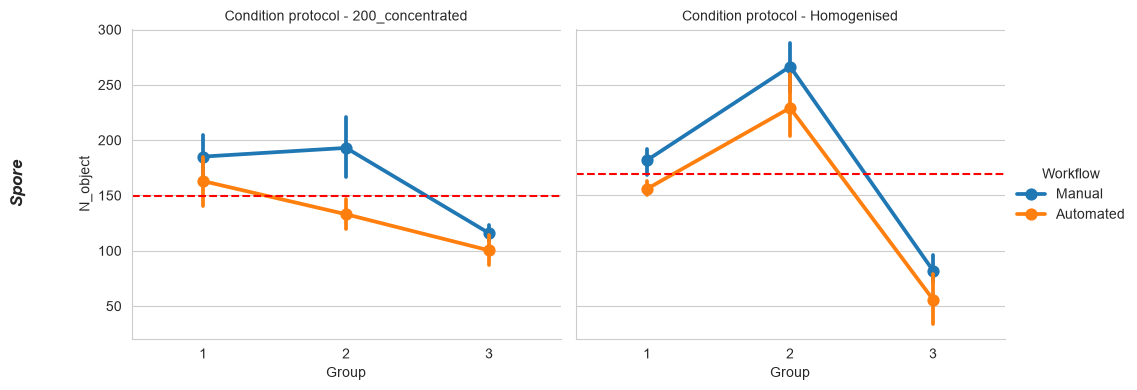

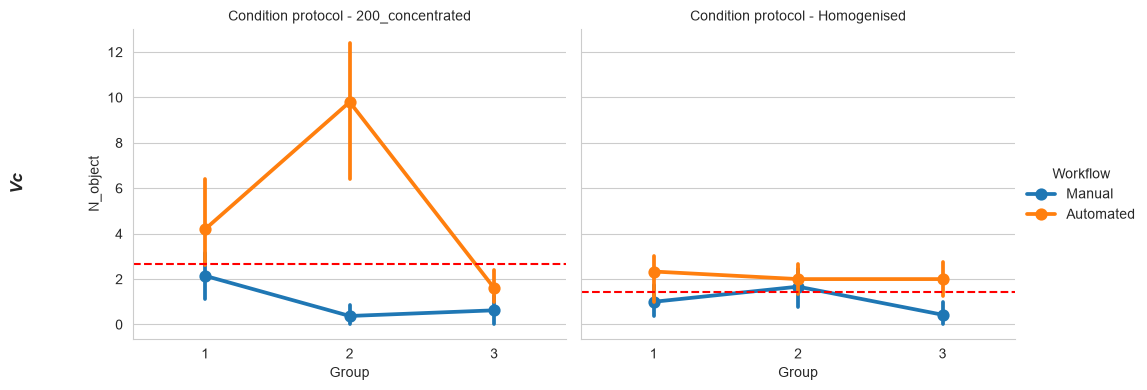

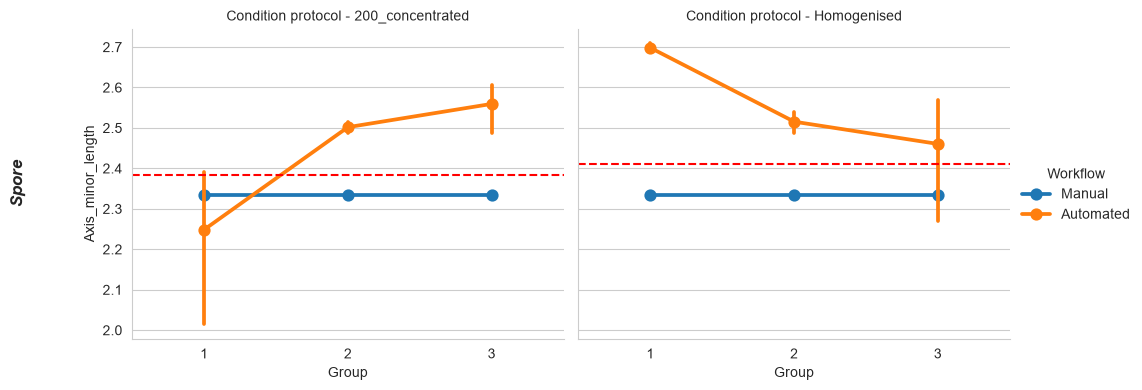

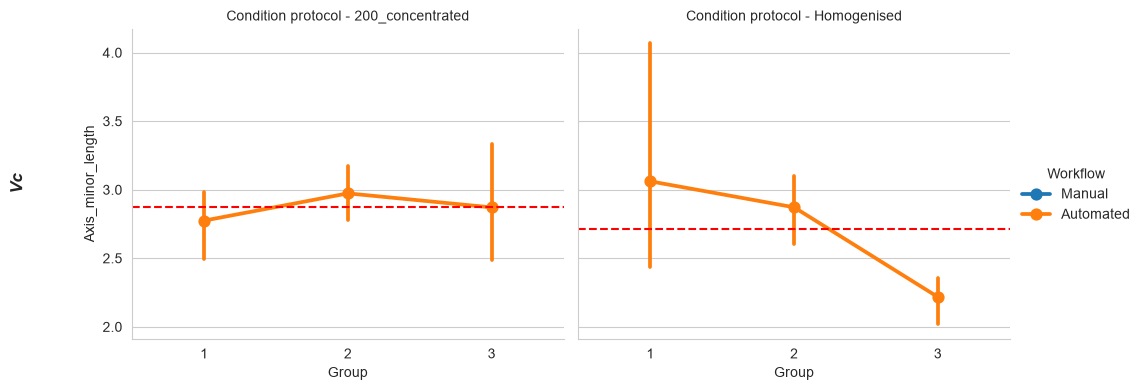

In [95]:
# Plot N_objects and length diameter (spores only)
cols = ['N_object', 'Axis_minor_length']

sns.set_style("whitegrid")

for col in cols:

    for ctype in df_aw_mw['Object_type'].unique():

        subset = df_aw_mw[
            df_aw_mw['Object_type'] == ctype
        ]

        g = sns.catplot(
            data=subset,
            x="Group",
            y=col,
            hue="Workflow",
            col="Condition_protocol",
            kind="point",
            height=4,
            aspect=1.2,
        )

        for ax, condition in zip(g.axes.flat, subset['Condition_protocol'].unique()):

            subset_condition = subset[
                subset['Condition_protocol'] == condition
            ]

            mean_value = subset_condition[col].mean()

            ax.axhline(
                mean_value,
                color='red',
                linestyle='--',
                linewidth=1.5
            )

        g.set_axis_labels("Group", col)
        g.set_titles("Condition protocol - {col_name}")

        ax.text(
            -1.3, 0.5,
            f"{ctype}",
            transform=ax.transAxes,
            rotation=90,
            ha="center",
            va="center",
            fontsize=12,
            fontweight='semibold',
            fontstyle='italic'
        )

        plt.show()